# Étape 1 — Chargement et préparation des données (MVTec AD — `pill`)

TP B6, partie 1. Plan du notebook :
1. Analyse préliminaire du jeu de données
2. Caractéristiques des images
3. Normalisation
4. Livrable
5. Recommandations

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from indusense.vision.dataset import (
    DATA_ROOT,
    DEFAULT_IMAGE_SIZE,
    list_defects,
    load_defect_images,
    load_good_images,
    train_val_split,
)

IMAGE_SIZE = DEFAULT_IMAGE_SIZE
SEED = 42
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Analyse préliminaire du jeu de données

Aperçu de la structure du dataset avant tout traitement : catégories de défauts disponibles et effectifs par split.

In [2]:
defects = list_defects()
print(f"Catégories de défauts : {defects}")


def count_images(folder):
    return len(list(folder.glob("*.png")))


print(f"train/good : {count_images(DATA_ROOT / 'train' / 'good')} images")
print(f"test/good  : {count_images(DATA_ROOT / 'test' / 'good')} images")
print()
print("Effectifs par catégorie de défaut (test/) :")
for defect in defects:
    print(f"  {defect}: {count_images(DATA_ROOT / 'test' / defect)}")

Catégories de défauts : ['color', 'combined', 'contamination', 'crack', 'faulty_imprint', 'pill_type', 'scratch']
train/good : 267 images
test/good  : 26 images

Effectifs par catégorie de défaut (test/) :
  color: 25
  combined: 17
  contamination: 21
  crack: 26
  faulty_imprint: 19
  pill_type: 9
  scratch: 24


## 2. Caractéristiques des images

Analyse d'un échantillon d'images brutes (avant redimensionnement/normalisation) : résolution native, contraste fond/objet, centrage et variabilité d'orientation — utile pour calibrer les augmentations de l'étape 2.

In [3]:
raw_sample = sorted((DATA_ROOT / "train" / "good").glob("*.png"))[0]
with Image.open(raw_sample) as raw_img:
    print(f"Résolution native : {raw_img.size}, mode {raw_img.mode}")
    raw_rgb = np.asarray(raw_img.convert("RGB"))
    raw_gray = np.asarray(raw_img.convert("L"))

h, w = raw_gray.shape
corner = raw_rgb[0:20, 0:20].reshape(-1, 3).mean(axis=0)
center = raw_rgb[h // 2 - 20 : h // 2 + 20, w // 2 - 20 : w // 2 + 20].reshape(-1, 3).mean(axis=0)
print(f"Fond (coin) RGB moyen : {corner.round(1)} | Objet (centre) RGB moyen : {center.round(1)}")

raw_paths = sorted((DATA_ROOT / "train" / "good").glob("*.png"))[:20]
centroids, ratios = [], []
for p in raw_paths:
    with Image.open(p) as img:
        gray = np.asarray(img.convert("L"))
    mask = gray > 60
    ys, xs = np.where(mask)
    centroids.append((ys.mean(), xs.mean()))
    ratios.append((ys.max() - ys.min()) / (xs.max() - xs.min()))

centroids = np.array(centroids)
print(f"Centroïde moyen (y, x) : {centroids.mean(axis=0).round(1)} (écart-type {centroids.std(axis=0).round(2)})")
print(f"Ratio bbox hauteur/largeur : min={min(ratios):.3f} max={max(ratios):.3f}")

Résolution native : (800, 800), mode RGB
Fond (coin) RGB moyen : [12.4 12.1 21.2] | Objet (centre) RGB moyen : [182.5 182.3 182.1]


Centroïde moyen (y, x) : [400.6 400.3] (écart-type [0.3  0.25])
Ratio bbox hauteur/largeur : min=0.683 max=0.917


## 3. Normalisation

Chargement des images saines : conversion RGB, redimensionnement (rééchantillonnage bicubique), normalisation en float32 dans `[0, 1]`. Une fraction de `train/good` est réservée pour la validation (graine fixe, `train_val_split`), qui servira à calibrer le seuil de détection en partie 2.

In [4]:
good_train = load_good_images("train", IMAGE_SIZE)
good_train, good_val = train_val_split(good_train, val_fraction=0.15, seed=SEED)
good_test = load_good_images("test", IMAGE_SIZE)

print(f"Saines train : {good_train.shape} | Saines val : {good_val.shape} | Saines test : {good_test.shape}")
print(f"min={good_train.min():.3f} max={good_train.max():.3f} dtype={good_train.dtype}")

Saines train : (227, 256, 256, 3) | Saines val : (40, 256, 256, 3) | Saines test : (26, 256, 256, 3)
min=0.016 max=0.969 dtype=float32


## 4. Livrable — saines vs défauts après chargement/normalisation

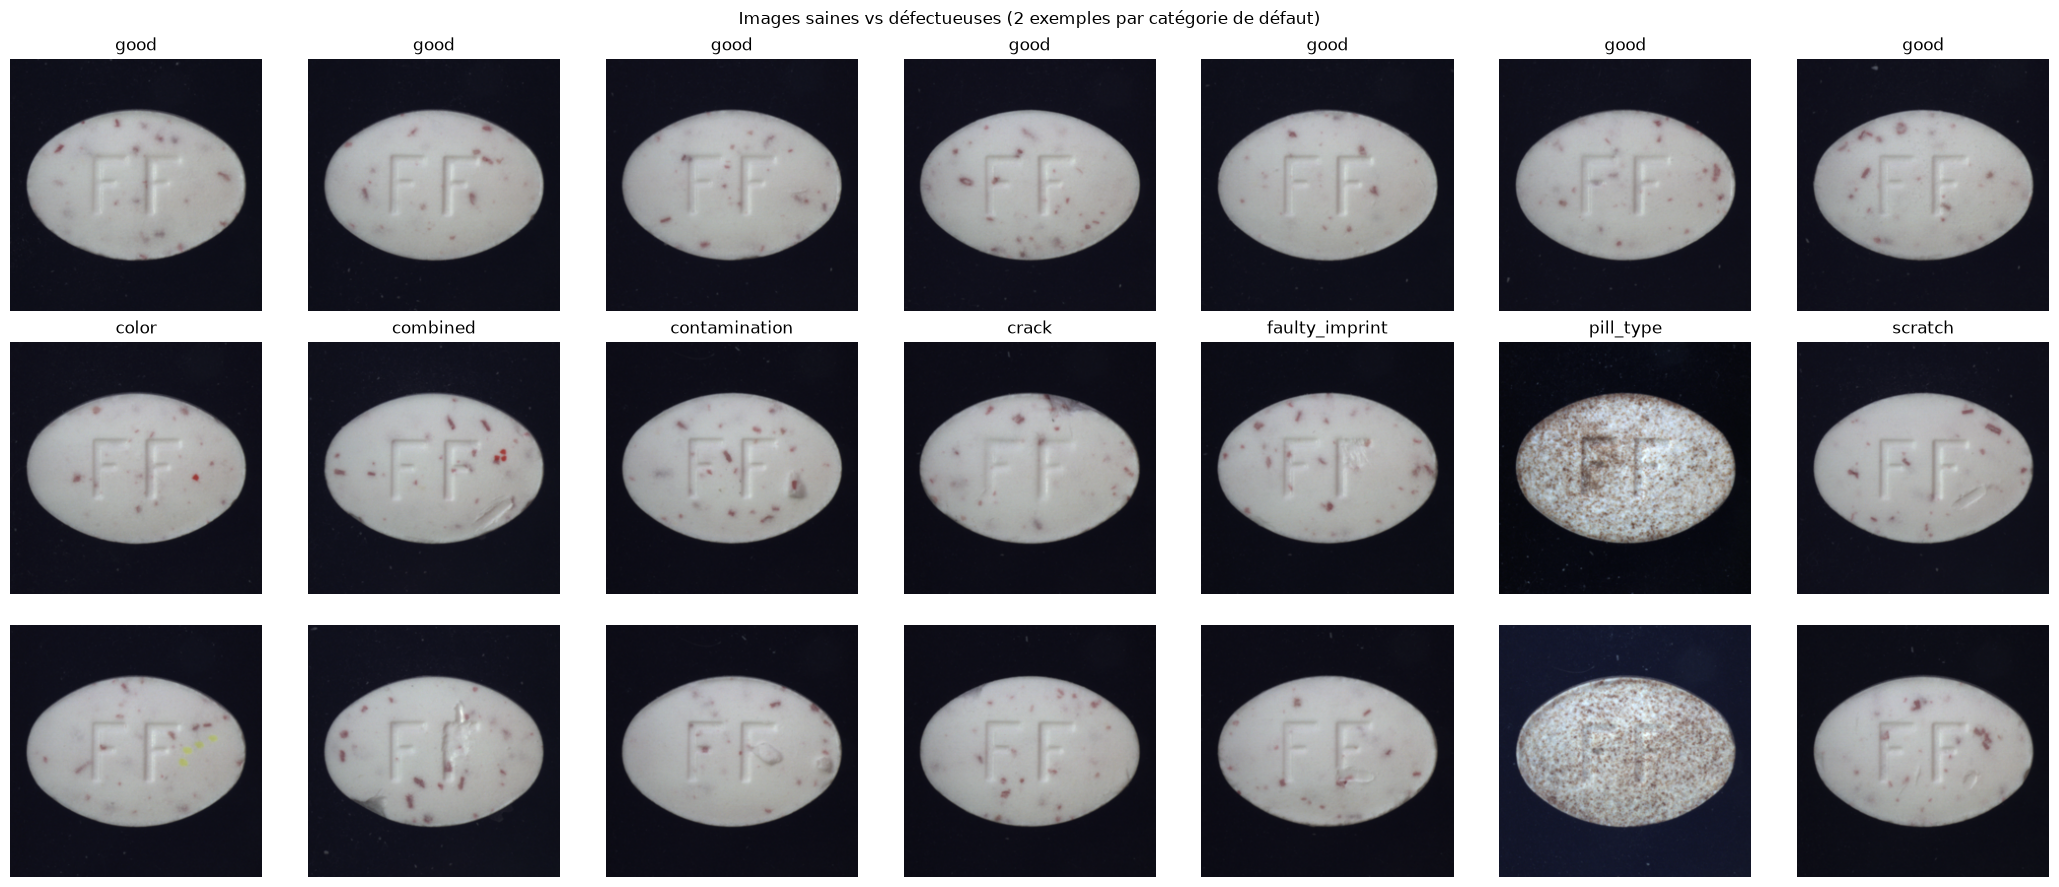

In [5]:
n_examples = 2
defect_samples = {defect: load_defect_images(defect, IMAGE_SIZE)[:n_examples] for defect in defects}

fig, axes = plt.subplots(1 + n_examples, len(defects), figsize=(3 * len(defects), 3 * (1 + n_examples)))
for col, defect in enumerate(defects):
    axes[0, col].imshow(good_test[col])
    axes[0, col].set_title("good")
    axes[0, col].axis("off")
    for row in range(n_examples):
        axes[1 + row, col].imshow(defect_samples[defect][row])
        axes[1 + row, col].set_title(defect if row == 0 else None)
        axes[1 + row, col].axis("off")
fig.suptitle("Images saines vs défectueuses (2 exemples par catégorie de défaut)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_sain_vs_defaut.png", dpi=150)
plt.show()

## 5. Recommandations pour les augmentations (étape 2)

À partir des constats des sections 1 à 3 :

- Le centrage quasi parfait et la largeur fixe (section 2) justifient des amplitudes de translation/échelle modérées (~5 %) plutôt que fortes.
- La variabilité de tilt déjà observée dans les données saines (section 2) rend plausible une rotation légère (±15°) — elle ne fait qu'amplifier une variation déjà réelle.
- La catégorie de défaut `color` (section 1) interdit toute augmentation de teinte/saturation forte (seul un ajustement modéré de luminosité/contraste est sûr), sous peine de brouiller un signal de défaut réel.
- La gravure fine « FF » et la catégorie `faulty_imprint` interdisent flou fort et déformations élastiques, qui effaceraient ou simuleraient ce défaut.
- Les défauts `crack`/`scratch` étant des textures linéaires fines, tout bruit géométrique (grid distortion) risquerait de générer des artefacts ressemblant à de faux défauts.
- Le fond uniforme (section 2) ne nécessite aucune augmentation dédiée : la variabilité à couvrir concerne uniquement l'objet.